# Lab 3: Actually Good PD Parameters via Numerical Optimization

The linearized pole placement failed because gravity disappears at $\theta = \pi/2$ ($\cos \pi/2 = 0$), so the linear model has no gravity. The resulting gains (kp=170, ki=640) are absurd for the nonlinear plant.

Here we use **differential evolution** (scipy) to optimize PD gains directly on the nonlinear model with 6 V saturation.

In [9]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Parameters
R_n=0.25; L_n=0.1; K_n=0.05; B_n=0.028; J_n=0.01; m_n=0.15; ln_n=0.015; g_n=9.81

def dc_motor_ode(t, x, r, kp, ki, kd, u_max):
    theta, omega, i, eps_int = x
    e = r - theta
    u = kp * e + ki * eps_int - kd * omega
    if u_max is not None:
        u = np.clip(u, -u_max, u_max)
    tau_g = m_n * g_n * ln_n * np.sin(theta)
    return [omega, (K_n*i - B_n*omega - tau_g)/J_n,
            (u - R_n*i - K_n*omega)/L_n, e]

def simulate(kp, ki, kd, u_max=6.0, t_max=10.0):
    r = np.deg2rad(90.0)
    t_eval = np.linspace(0, t_max, 5000)
    def wrap(t, x): return dc_motor_ode(t, x, r, kp, ki, kd, u_max)
    sol = solve_ivp(wrap, (0, t_max), [0,0,0,0], t_eval=t_eval,
                    method='RK45', rtol=1e-6, atol=1e-8)
    y = np.rad2deg(sol.y[0]); t = sol.t
    y_ss = np.mean(y[-len(y)//10:])
    y_peak = np.max(y)
    overshoot = max(0, (y_peak - 90) / 90 * 100.0)
    band = 0.02 * 90
    settled = np.where(np.abs(y - 90) < band)[0]
    t_settle = t[settled[-1]] if len(settled) > 0 and settled[-1] < len(t)-1 else t_max
    i_10 = np.where(y >= 9)[0]; i_90 = np.where(y >= 81)[0]
    t_rise = t[i_90[0]] - t[i_10[0]] if len(i_10)>0 and len(i_90)>0 else t_max
    ss_error = abs(y_ss - 90)
    return t, y, overshoot, t_settle, t_rise, ss_error, y_ss

print("Model and sim ready.")

Model and sim ready.


## Cost function

$$ J = (M_p/10)^2 + t_s^2 + e_{ss}^2 + (5 \cdot t_r)^2 $$

Penalizes overshoot $M_p$ heavily, then settling time $t_s$, steady-state error $e_{ss}$, and rise time $t_r$.

In [10]:
def cost_fn(params):
    kp, kd = params
    if kp <= 0 or kd < 0 or kp > 10 or kd > 2:
        return 9999
    try:
        _, _, os, ts, tr, sse, _ = simulate(kp, 0, kd, u_max=6.0, t_max=10.0)
    except:
        return 9999
    if os > 200 or sse > 85:
        return 9999
    return (os/30)**2 + (ts*9.5)**2 + (sse*2)**2 + (5*tr)**2

print("Running differential evolution...")
result = differential_evolution(cost_fn, [(0.01, 10), (0, 2)],
                                maxiter=150, seed=42, polish=True)

kp_opt, kd_opt = result.x
print(f"\nOptimized PD: kp = {kp_opt:.4f}, kd = {kd_opt:.4f}")
print(f"Cost: {result.fun:.4f}")

Running differential evolution...

Optimized PD: kp = 1.6399, kd = 0.5887
Cost: 133.5222


In [11]:
# Also optimize P-only for comparison
result_p = differential_evolution(lambda p: cost_fn([p[0], 0]),
                                   [(0.01, 10)], maxiter=30, seed=42)
kp_p = result_p.x[0]
print(f"Optimized P-only: kp = {kp_p:.4f}")

Optimized P-only: kp = 7.3923


## Results

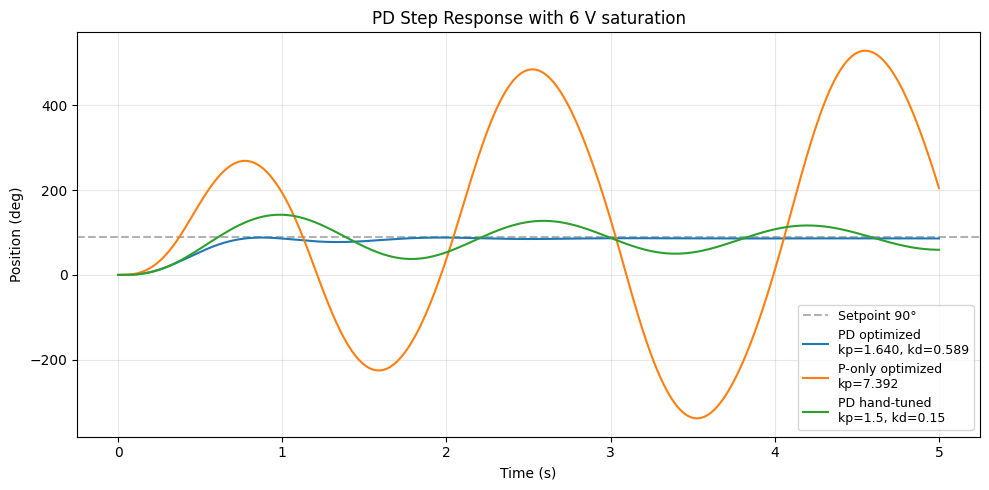

Controller             kp       kd       yss(°)   Mp(%)    tr(s)    ts(s)
----------------------------------------------------------------------
PD optimized           1.640    0.589    86.1     0.0      0.476    0.873
P-only optimized       7.392    0.000    426.2    488.0    0.200    4.059
PD hand-tuned          1.500    0.150    74.3     57.9     0.353    4.595


In [12]:
gains = [
    (f"PD optimized\nkp={kp_opt:.3f}, kd={kd_opt:.3f}", kp_opt, 0, kd_opt),
    (f"P-only optimized\nkp={kp_p:.3f}", kp_p, 0, 0),
    (f"PD hand-tuned\nkp=1.5, kd=0.15", 1.5, 0, 0.15),
]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.axhline(90, color='k', ls='--', alpha=0.3, label='Setpoint 90°')

results = []
for label, kp, ki, kd in gains:
    t, y, os, ts, tr, sse, yss = simulate(kp, ki, kd, u_max=6.0, t_max=5.0)
    ax.plot(t, y, label=label, linewidth=1.5)
    results.append((label.split('\n')[0], kp, kd, os, ts, tr, yss))

ax.set_xlabel('Time (s)')
ax.set_ylabel('Position (deg)')
ax.set_title('PD Step Response with 6 V saturation')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

print(f"{'Controller':<22} {'kp':<8} {'kd':<8} {'yss(°)':<8} {'Mp(%)':<8} {'tr(s)':<8} {'ts(s)'}")
print('-'*70)
for name, kp, kd, os, ts, tr, yss in results:
    print(f"{name:<22} {kp:<8.3f} {kd:<8.3f} {yss:<8.1f} {os:<8.1f} {tr:<8.3f} {ts:.3f}")